In [26]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [27]:
# Load Tesla stock data from Yahoo Finance
tesla = yf.Ticker("TSLA")
df = tesla.history(period="2y")  # last 2 years

# Reset index so Date becomes a column
df.reset_index(inplace=True)

df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2024-03-20 00:00:00-04:00,173.000000,176.250000,170.820007,175.660004,83846700,0.0,0.0
1,2024-03-21 00:00:00-04:00,176.389999,178.179993,171.800003,172.820007,73178000,0.0,0.0
2,2024-03-22 00:00:00-04:00,166.690002,171.199997,166.300003,170.830002,75580600,0.0,0.0
3,2024-03-25 00:00:00-04:00,168.759995,175.240005,168.729996,172.630005,74228600,0.0,0.0
4,2024-03-26 00:00:00-04:00,178.580002,184.250000,177.380005,177.669998,113186200,0.0,0.0


In [28]:
# Check structure
print(df.info())

# Drop missing values
df = df.dropna()

# Create additional features (helps meet assignment requirements)
df["Price_Change"] = df["Close"] - df["Open"]
df["Daily_Return"] = df["Close"].pct_change()
df["Direction"] = df["Price_Change"].apply(lambda x: "Up" if x > 0 else "Down")

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                          
---  ------        --------------  -----                          
 0   Date          501 non-null    datetime64[s, America/New_York]
 1   Open          501 non-null    float64                        
 2   High          501 non-null    float64                        
 3   Low           501 non-null    float64                        
 4   Close         501 non-null    float64                        
 5   Volume        501 non-null    int64                          
 6   Dividends     501 non-null    float64                        
 7   Stock Splits  501 non-null    float64                        
dtypes: datetime64[s, America/New_York](1), float64(6), int64(1)
memory usage: 31.4 KB
None


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Price_Change,Daily_Return,Direction
0,2024-03-20 00:00:00-04:00,173.000000,176.250000,170.820007,175.660004,83846700,0.0,0.0,2.660004,NaN,Up
1,2024-03-21 00:00:00-04:00,176.389999,178.179993,171.800003,172.820007,73178000,0.0,0.0,-3.569992,-0.016168,Down
2,2024-03-22 00:00:00-04:00,166.690002,171.199997,166.300003,170.830002,75580600,0.0,0.0,4.139999,-0.011515,Up
3,2024-03-25 00:00:00-04:00,168.759995,175.240005,168.729996,172.630005,74228600,0.0,0.0,3.870010,0.010537,Up
4,2024-03-26 00:00:00-04:00,178.580002,184.250000,177.380005,177.669998,113186200,0.0,0.0,-0.910004,0.029195,Down


In [29]:
# Summary stats
summary = df.describe()
print(summary)

# Median separately (since describe doesn't emphasize it clearly)
print("\nMedian values:\n", df.median(numeric_only=True))

             Open        High         Low       Close        Volume  \
count  501.000000  501.000000  501.000000  501.000000  5.010000e+02   
mean   317.022246  323.723503  310.060459  316.996886  9.155829e+07   
std     95.560517   96.840331   93.661295   95.216924  3.500542e+07   
min    140.559998  144.440002  138.800003  142.050003  3.625290e+07   
25%    231.610001  241.410004  226.550003  232.100006  6.701890e+07   
50%    323.079987  330.489990  316.859985  323.630005  8.328360e+07   
75%    409.700012  416.899994  400.510010  408.579987  1.055067e+08   
max    489.880005  498.829987  485.329987  489.880005  2.874998e+08   

       Dividends  Stock Splits  Price_Change  Daily_Return  
count      501.0         501.0    501.000000    500.000000  
mean         0.0           0.0     -0.025359      0.002307  
std          0.0           0.0      9.428251      0.039371  
min          0.0           0.0    -37.789978     -0.154262  
25%          0.0           0.0     -4.700012     -0.020

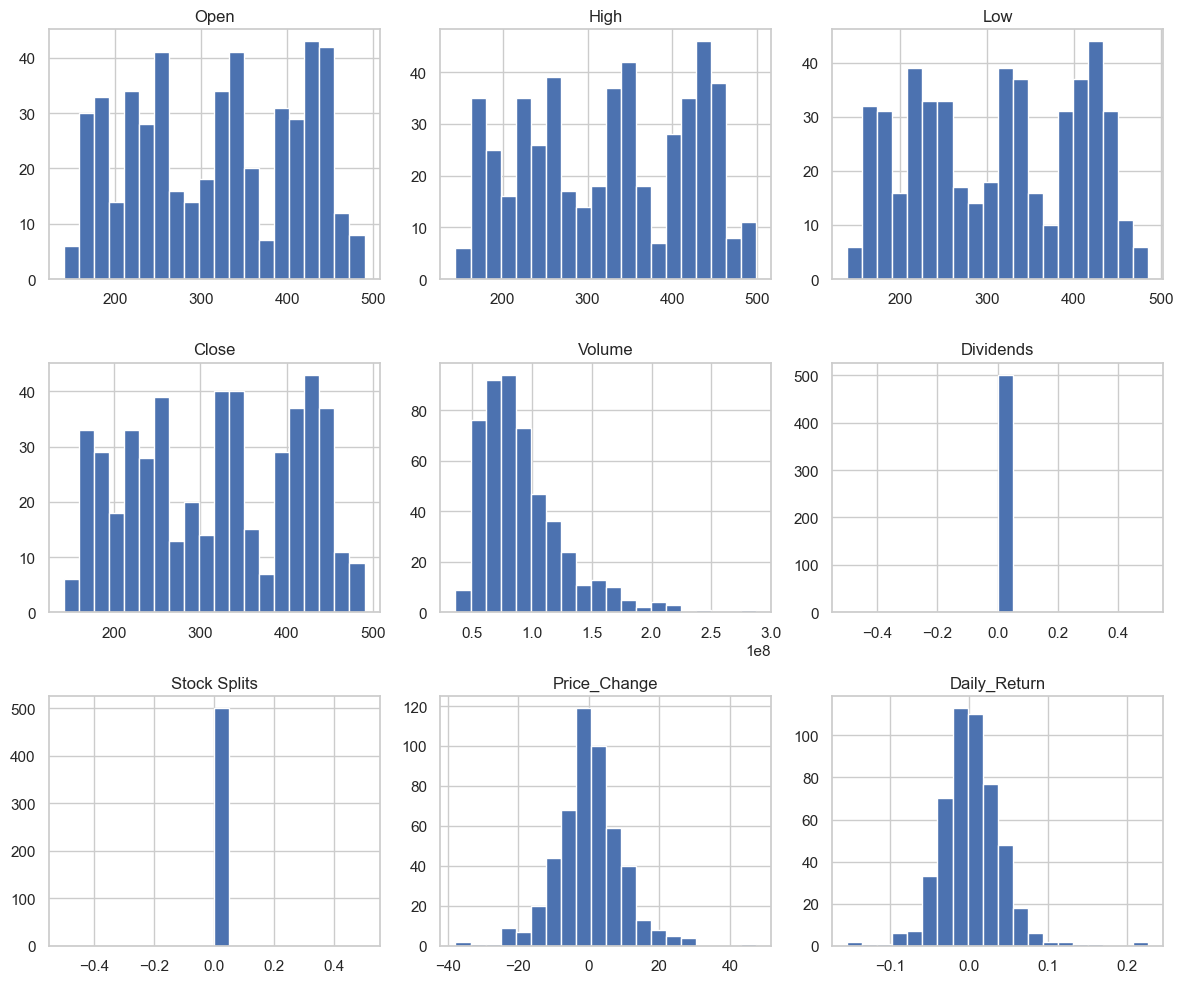

In [30]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[num_cols].hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

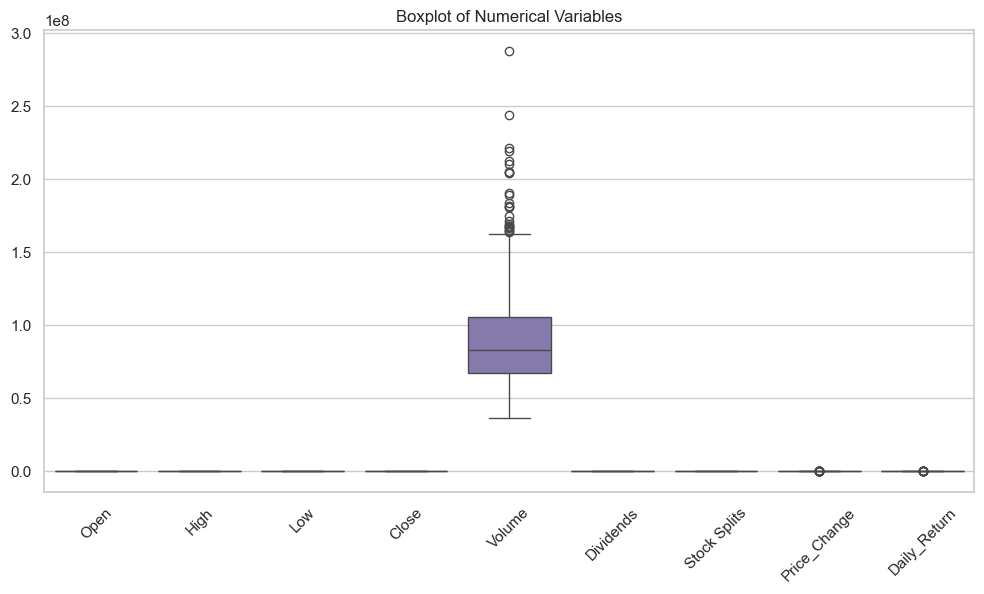

In [31]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Variables")
plt.show()

In [32]:
# IQR method
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | 
            (df[num_cols] > (Q3 + 1.5 * IQR)))

print("Outliers per column:\n", outliers.sum())

Outliers per column:
 Open             0
High             0
Low              0
Close            0
Volume          25
Dividends        0
Stock Splits     0
Price_Change    29
Daily_Return    13
dtype: int64


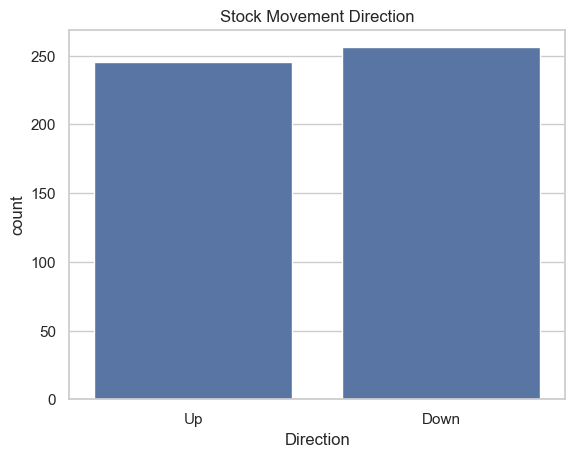

In [33]:
sns.countplot(x="Direction", data=df)
plt.title("Stock Movement Direction")
plt.show()

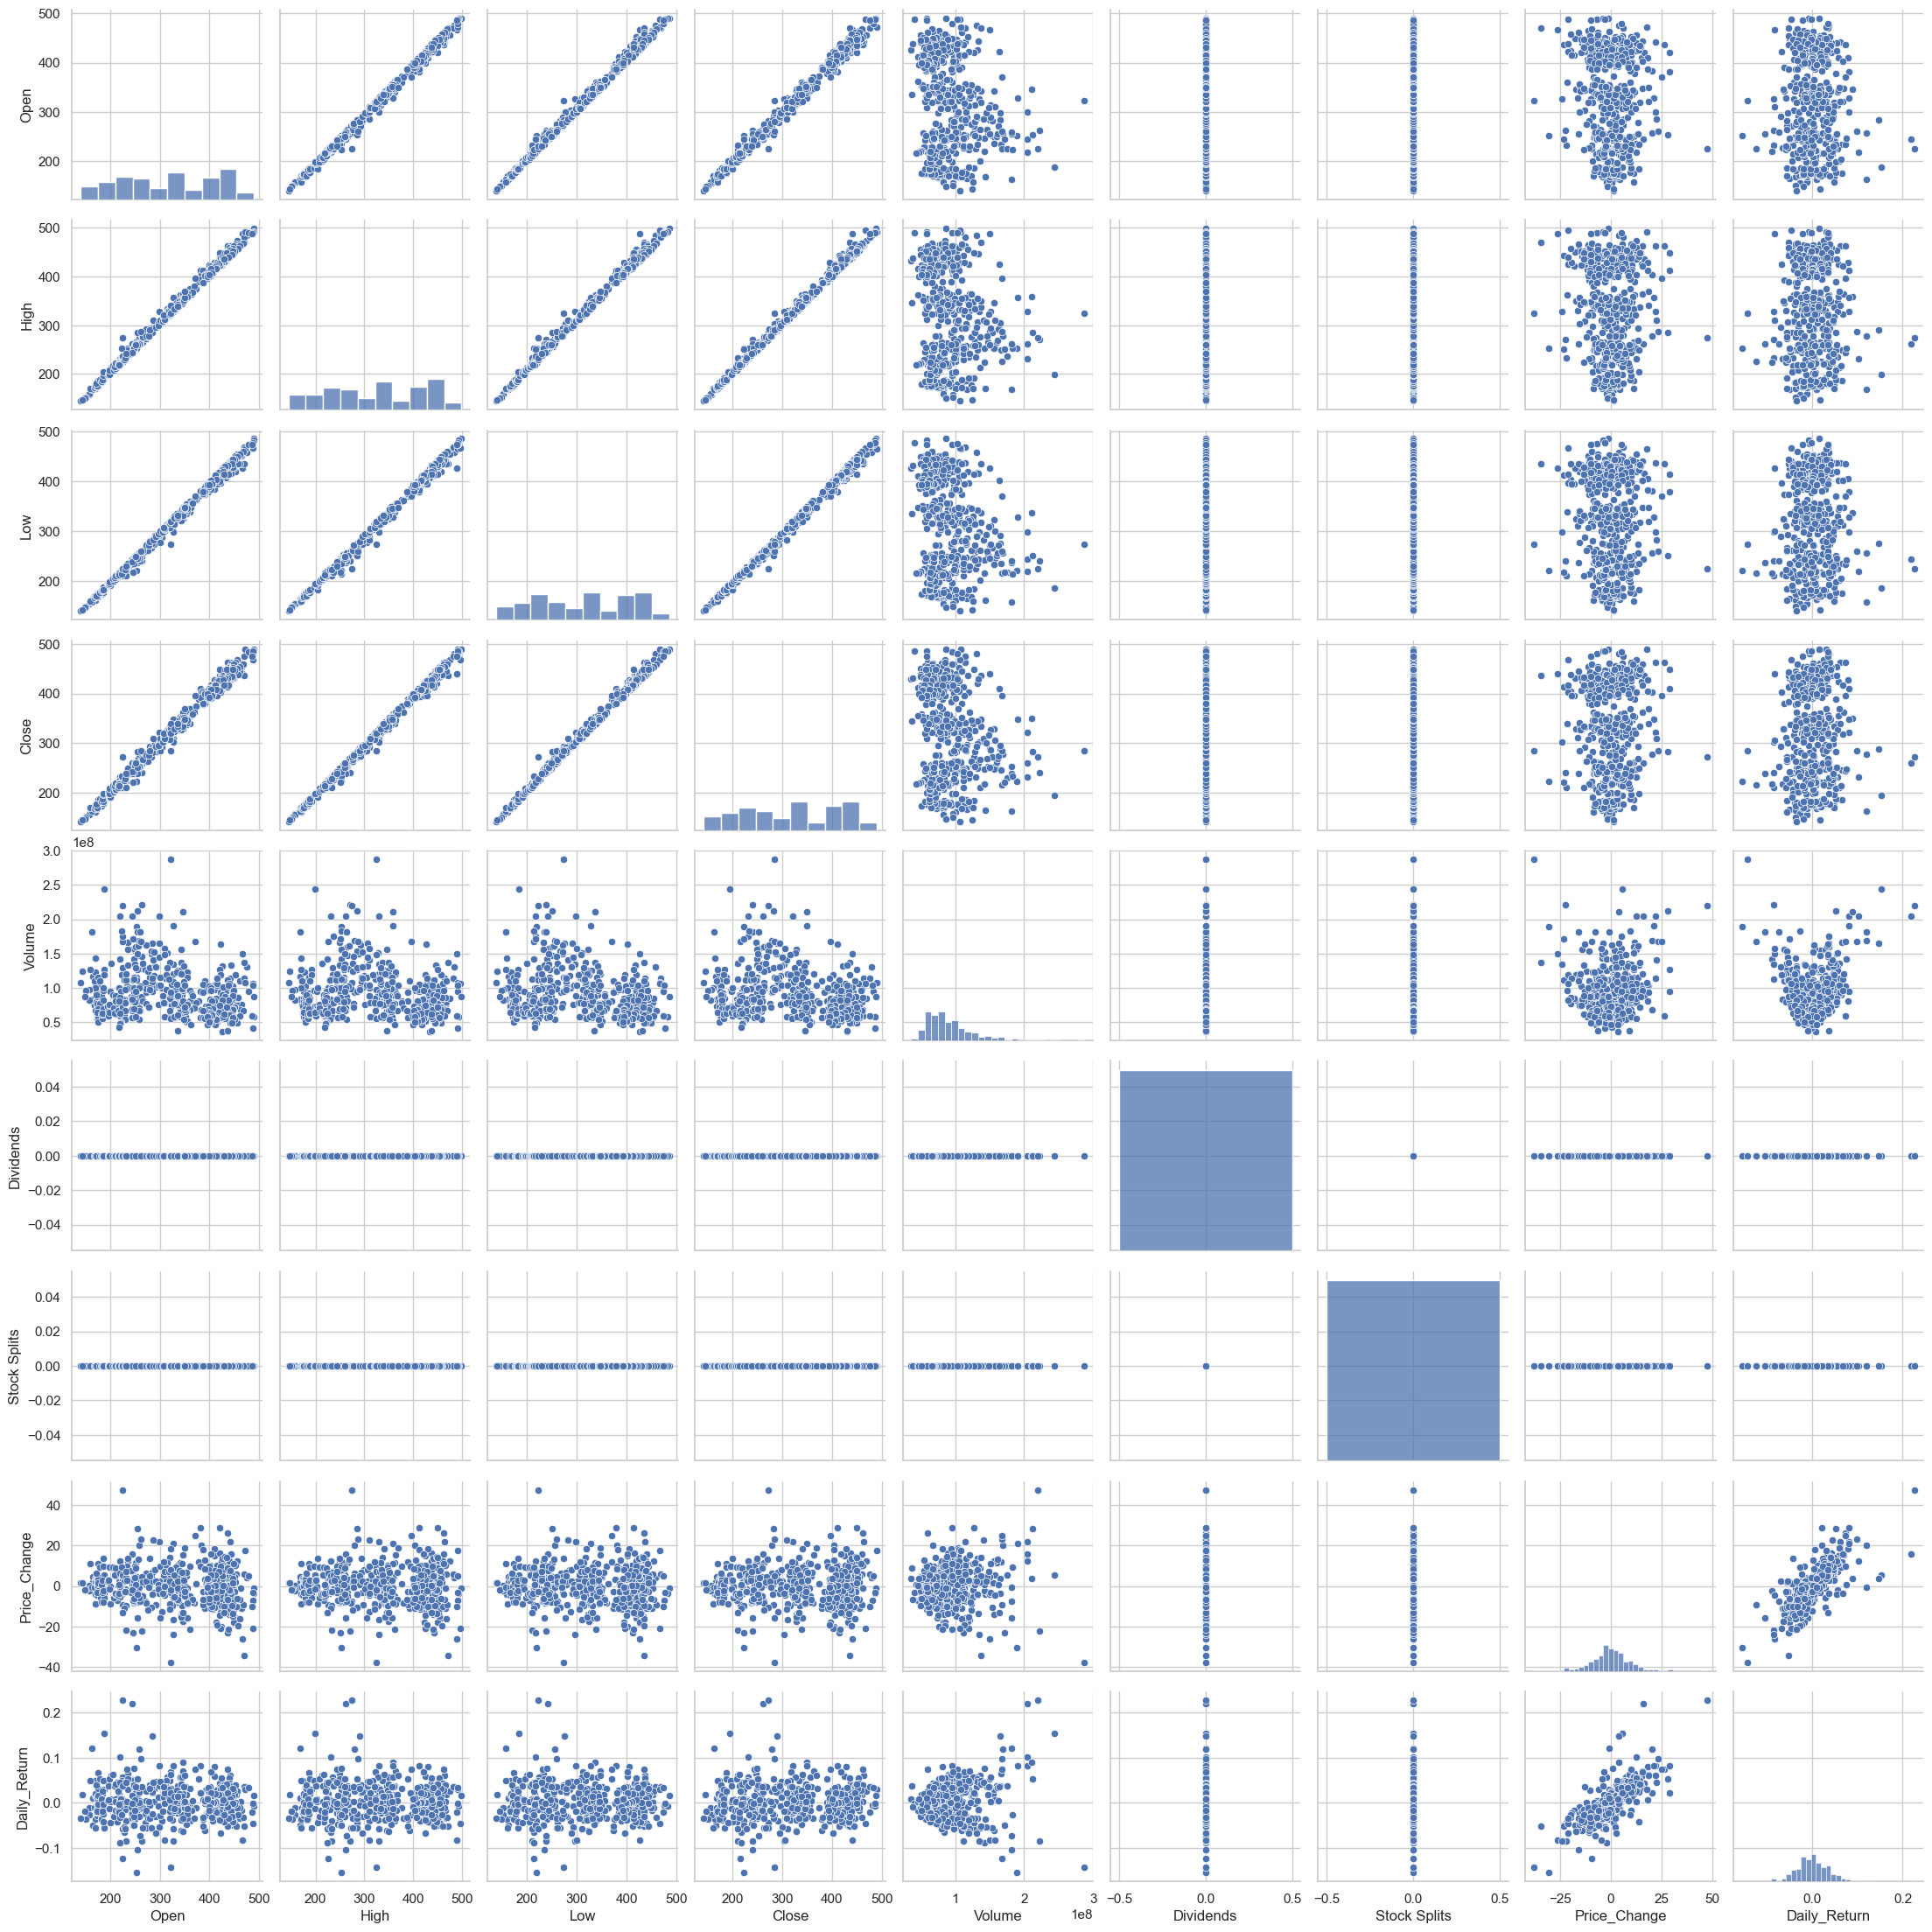

In [34]:
sns.pairplot(df[num_cols])
plt.show()

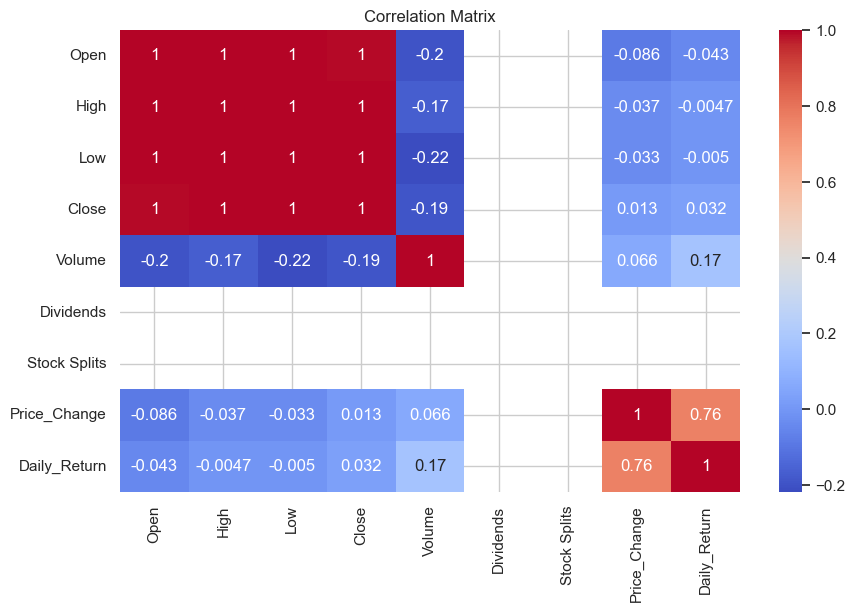

In [35]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [36]:
pd.crosstab(df["Direction"], df["Date"].dt.month)

Date,1,2,3,4,5,6,7,8,9,10,11,12
Direction,,,,,,,,,,,,
Down,23,20,20,20,19,25,19,24,16,27,20,23
Up,17,18,22,23,24,14,25,19,25,19,19,20


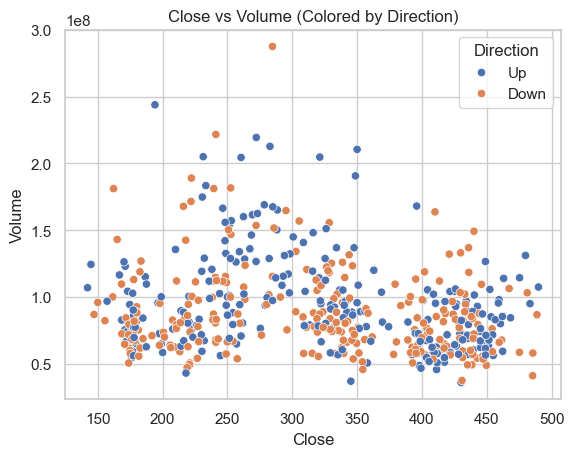

In [37]:
sns.scatterplot(x="Close", y="Volume", hue="Direction", data=df)
plt.title("Close vs Volume (Colored by Direction)")
plt.show()

In [38]:
df.groupby("Direction")["Close"].mean()

Direction
Down    314.125000
Up      319.997714
Name: Close, dtype: float64